In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split

torch.manual_seed(42)

In [25]:
CSV_FILENAME = "clean_autonomous_taxi_rides.csv"

In [26]:
df = pd.read_csv(CSV_FILENAME)
df.head(5)

,trip_distance_miles,pickup_hour,passenger_count,ride_duration_min
0,2.5,8,1,9.0
1,4.0,9,1,12.0
2,6.0,17,2,18.0
3,8.5,18,2,24.0
4,10.0,7,1,27.0


In [27]:
duration_col = "ride_duration_min"
MAX_ACCEPTABLE_DURATION_MIN = 25.0
df["accept_request"] = (df[duration_col] <= MAX_ACCEPTABLE_DURATION_MIN).astype("float32")
df

,trip_distance_miles,pickup_hour,passenger_count,ride_duration_min,accept_request
0,2.5,8,1,9.0,1.0
1,4.0,9,1,12.0,1.0
2,6.0,17,2,18.0,1.0
3,8.5,18,2,24.0,1.0
4,10.0,7,1,27.0,0.0
5,12.0,12,3,31.0,0.0
6,15.0,16,2,39.0,0.0
7,18.0,20,1,46.0,0.0


In [28]:
df["accept_request"].value_counts().sort_index()

accept_request
0.0    4
1.0    4
Name: count, dtype: int64

In [29]:
feature_col = "trip_distance_miles"
target_col = "accept_request"
df[[feature_col, target_col]]

,trip_distance_miles,accept_request
0,2.5,1.0
1,4.0,1.0
2,6.0,1.0
3,8.5,1.0
4,10.0,0.0
5,12.0,0.0
6,15.0,0.0
7,18.0,0.0


In [30]:
x = df[[feature_col]].values.astype("float32")
y = df[[target_col]].values.astype("float32")

In [31]:
print("x shape:", x.shape)
print("y shape:", y.shape)

x shape: (8, 1)
y shape: (8, 1)


In [32]:
x_train_np, x_test_np, y_train_np, y_test_np = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42)

In [33]:
print("x_train_shape:", x_train_np.shape)
print("x_test_shape:", x_test_np.shape)
print("y_train_shape:", y_train_np.shape)
print("y_test_shape:", y_test_np.shape)

x_train_shape: (6, 1)
x_test_shape: (2, 1)
y_train_shape: (6, 1)
y_test_shape: (2, 1)


In [34]:
x_train = torch.tensor(x_train_np, dtype=torch.float32)
x_test = torch.tensor(x_test_np, dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.float32)
y_test = torch.tensor(y_test_np, dtype=torch.float32)

print("x_train shape: ", x_train.shape)
print("x_test shape: ", x_test.shape)
print("y_train shape: ", y_train.shape)
print("x_test shape: ", y_test.shape)

x_train shape:  torch.Size([6, 1])
x_test shape:  torch.Size([2, 1])
y_train shape:  torch.Size([6, 1])
x_test shape:  torch.Size([2, 1])


In [35]:
x_train

tensor([[ 2.5000],
        [18.0000],
        [ 6.0000],
        [10.0000],
        [ 8.5000],
        [15.0000]])

In [36]:
y_train

tensor([[1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [0.]])

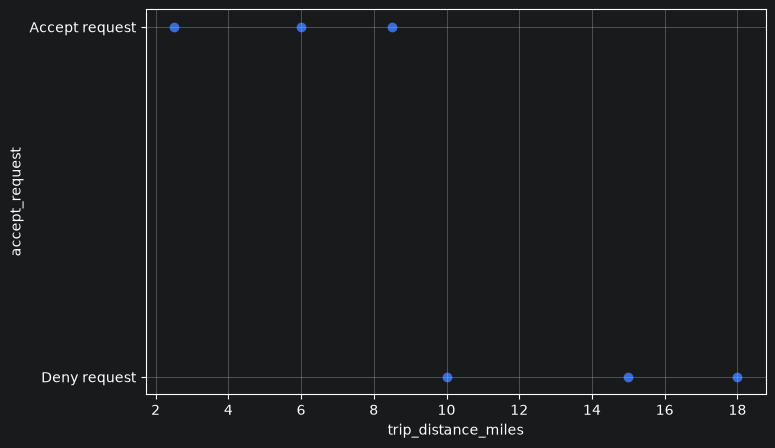

In [37]:
plt.figure(figsize=(8, 5))
plt.scatter(x_train_np, y_train_np)
plt.xlabel(feature_col)
plt.ylabel(target_col)
plt.yticks([0,1], ["Deny request","Accept request"])
plt.grid(True)
plt.show()